In [ ]:
# Sinusoidal Position Encoding — Interactive Demo
# Run in Google Colab: all cells are self-contained

# ── Cell 1: Install / imports ──────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch, Circle
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

In [ ]:
# ── Cell 2: Core functions ─────────────────────────────────────────────────

def sinusoidal_embedding(position, d_model=128):
    """
    Compute the sinusoidal position embedding for a single position.
    Returns a vector of shape (d_model,).
    """
    emb = np.zeros(d_model)
    for k in range(d_model // 2):
        denom = 10000 ** (2 * k / d_model)
        emb[2 * k]     = np.cos(position / denom)   # cos component
        emb[2 * k + 1] = np.sin(position / denom)   # sin component
    return emb


def compute_embedding_matrix(max_len=200, d_model=128):
    """
    Compute the full embedding matrix of shape (max_len, d_model).
    Row i contains the embedding for position i.
    """
    E = np.zeros((max_len, d_model))
    for i in range(max_len):
        E[i] = sinusoidal_embedding(i, d_model)
    return E

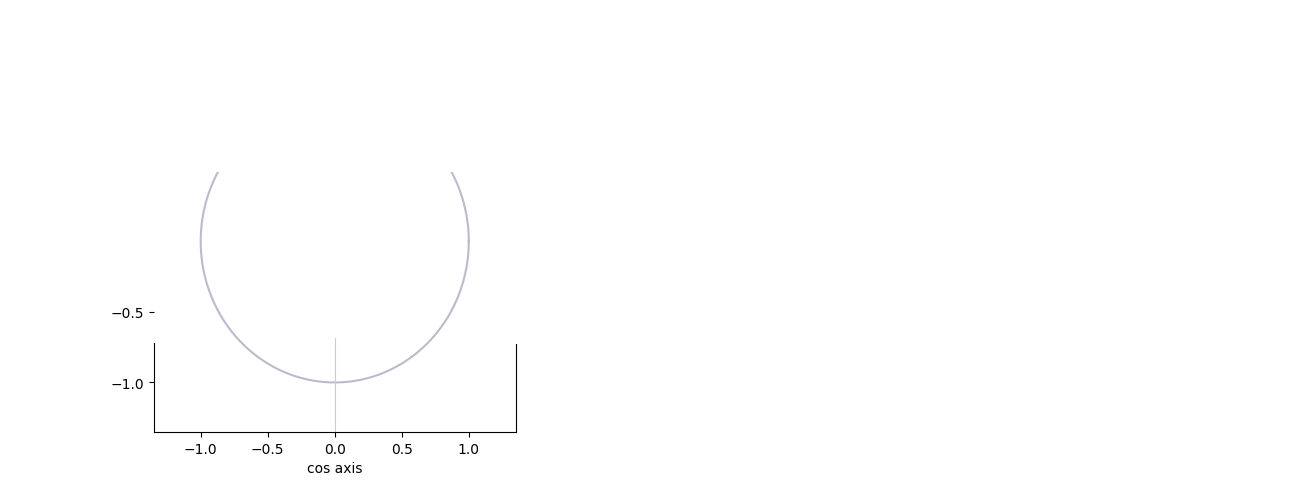

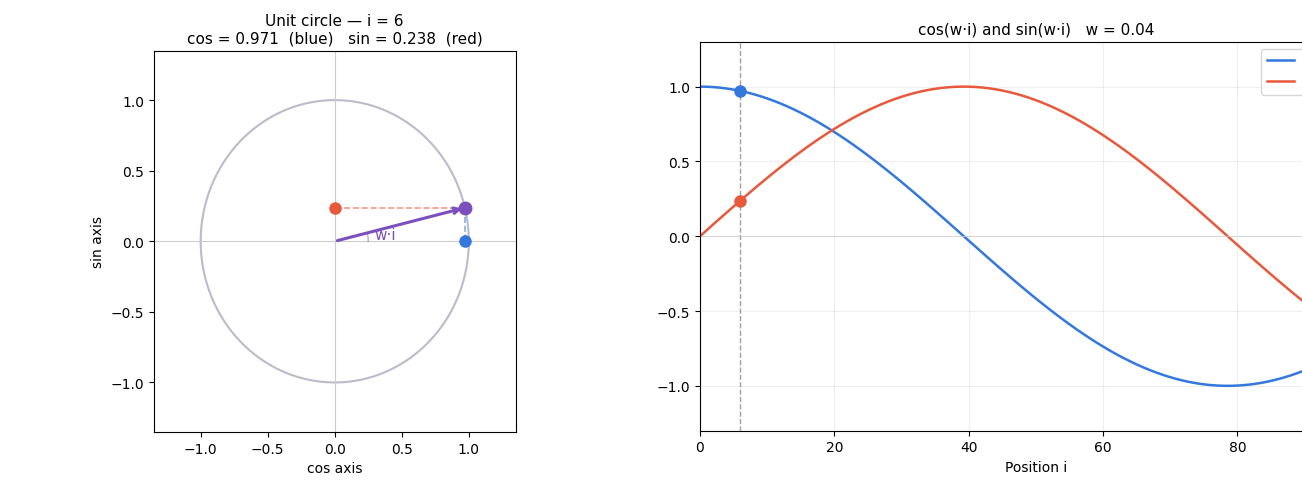

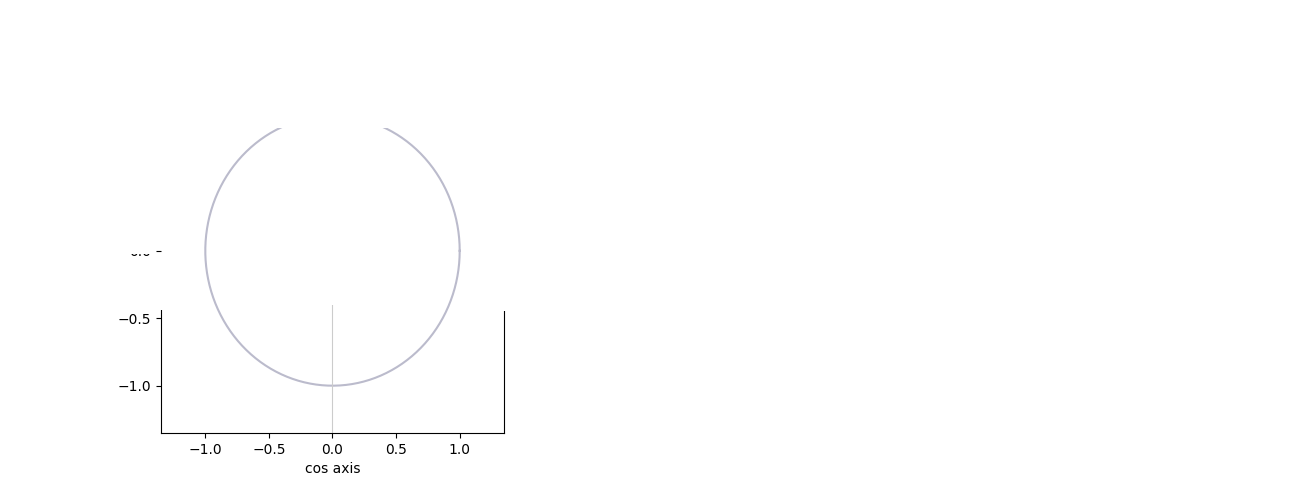

In [ ]:
# ── Cell 3: Static plot — unit circle + waveforms ─────────────────────────

def plot_unit_circle_and_waves(position=20, w_k=0.3, figsize=(14, 5)):
    """
    Left:  Unit circle showing the rotating 2D vector (cos(w*i), sin(w*i)).
    Right: cos and sin waves over positions 0..100 with a marker at `position`.
    """
    angle = w_k * position
    cos_val = np.cos(angle)
    sin_val = np.sin(angle)

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # ── Left: unit circle ──────────────────────────────────────────────────
    ax = axes[0]
    theta = np.linspace(0, 2 * np.pi, 400)
    ax.plot(np.cos(theta), np.sin(theta), color='#bbbbcc', lw=1.5, zorder=1)
    ax.axhline(0, color='#cccccc', lw=0.8)
    ax.axvline(0, color='#cccccc', lw=0.8)

    # Negate y to match canvas convention (clockwise rotation as i increases)
    sv = -sin_val

    # Dashed projections
    ax.plot([cos_val, cos_val], [sv, 0], '--', color='#3478dd',
            lw=1.2, alpha=0.6, zorder=2)
    ax.plot([cos_val, 0], [sv, sv], '--', color='#e8593c',
            lw=1.2, alpha=0.6, zorder=2)

    # Projection dots on axes
    ax.plot(cos_val, 0,  'o', color='#3478dd', ms=8, zorder=4)
    ax.plot(0,       sv, 'o', color='#e8593c', ms=8, zorder=4)

    # Rotating vector
    ax.annotate('', xy=(cos_val, sv), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#7c4fbf', lw=2.2))

    # Point on circle
    ax.plot(cos_val, sv, 'o', color='#7c4fbf', ms=9, zorder=5)

    # Angle arc (clockwise)
    arc_theta = np.linspace(0, -(angle % (2 * np.pi)), 60)
    ax.plot(0.25 * np.cos(arc_theta), 0.25 * np.sin(arc_theta),
            color='#7c4fbf', lw=1, alpha=0.5)
    mid = -angle / 2
    ax.text(0.38 * np.cos(mid), 0.38 * np.sin(mid), 'w·i',
            fontsize=11, color='#7c4fbf', ha='center', va='center')

    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect('equal')
    ax.set_title('Unit circle\n'
                 f'cos = {cos_val:.3f}  (blue dot)\n'
                 f'sin = {sin_val:.3f}  (red dot)', fontsize=11)
    ax.set_xlabel('cos axis')
    ax.set_ylabel('sin axis')

    # ── Right: waveforms ───────────────────────────────────────────────────
    ax2 = axes[1]
    positions = np.arange(0, 101)
    cos_wave = np.cos(w_k * positions)
    sin_wave = np.sin(w_k * positions)

    ax2.plot(positions, cos_wave, color='#3478dd', lw=1.8, label='cos(w·i)')
    ax2.plot(positions, sin_wave, color='#e8593c', lw=1.8, label='sin(w·i)')

    # Current position marker
    ax2.axvline(position, color='#444', lw=1, ls='--', alpha=0.5)
    ax2.plot(position, np.cos(w_k * position), 'o', color='#3478dd', ms=8, zorder=5)
    ax2.plot(position, np.sin(w_k * position), 'o', color='#e8593c', ms=8, zorder=5)

    ax2.axhline(0, color='#cccccc', lw=0.5)
    ax2.set_xlim(0, 100)
    ax2.set_ylim(-1.3, 1.3)
    ax2.set_xlabel('Position i')
    ax2.set_title(f'cos(w·i) and sin(w·i) over i = 0…100\n'
                  f'(current position i = {position}, w = {w_k:.2f})', fontsize=11)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()


# Show a static example
plot_unit_circle_and_waves(position=20, w_k=0.3)

In [16]:

# ── Cell 4: Interactive widget ────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import io

pos_slider = widgets.IntSlider(
    value=20, min=0, max=100, step=1,
    description='Position i:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='480px'))

freq_slider = widgets.FloatSlider(
    value=0.3, min=0.01, max=1.5, step=0.01,
    description='Frequency w_k:',
    style={'description_width': '100px'},
    layout=widgets.Layout(width='480px'))

img_widget = widgets.Image(format='png',
                           layout=widgets.Layout(width='100%'))

def make_figure(position, w_k):
    angle   = w_k * position
    cos_val = np.cos(angle)
    sin_val = np.sin(angle)
    sv      = -sin_val
    positions = np.arange(0, 101)

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), dpi=100)

    ax = axes[0]
    theta = np.linspace(0, 2 * np.pi, 400)
    ax.plot(np.cos(theta), np.sin(theta), color='#bbbbcc', lw=1.5)
    ax.axhline(0, color='#cccccc', lw=0.8)
    ax.axvline(0, color='#cccccc', lw=0.8)
    ax.plot([cos_val, cos_val], [sv, 0],  '--', color='#3478dd', lw=1.2, alpha=0.6)
    ax.plot([cos_val, 0],       [sv, sv], '--', color='#e8593c', lw=1.2, alpha=0.6)
    ax.plot(cos_val, 0,  'o', color='#3478dd', ms=8)
    ax.plot(0,       sv, 'o', color='#e8593c', ms=8)
    ax.annotate('', xy=(cos_val, sv), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#7c4fbf', lw=2.2))
    ax.plot(cos_val, sv, 'o', color='#7c4fbf', ms=9)
    arc_theta = np.linspace(0, -(angle % (2 * np.pi)), 60)
    ax.plot(0.25*np.cos(arc_theta), 0.25*np.sin(arc_theta),
            color='#7c4fbf', lw=1, alpha=0.5)
    mid = -angle / 2
    ax.text(0.38*np.cos(mid), 0.38*np.sin(mid), 'w·i',
            fontsize=11, color='#7c4fbf', ha='center', va='center')
    ax.set_xlim(-1.35, 1.35)
    ax.set_ylim(-1.35, 1.35)
    ax.set_aspect('equal')
    ax.set_title(f'Unit circle — i = {int(position)}\n'
                 f'cos = {cos_val:.3f}  (blue)   sin = {sin_val:.3f}  (red)',
                 fontsize=11)
    ax.set_xlabel('cos axis')
    ax.set_ylabel('sin axis')

    ax2 = axes[1]
    ax2.plot(positions, np.cos(w_k*positions), color='#3478dd', lw=1.8, label='cos(w·i)')
    ax2.plot(positions, np.sin(w_k*positions), color='#e8593c', lw=1.8, label='sin(w·i)')
    ax2.axvline(position, color='#444', lw=1, ls='--', alpha=0.5)
    ax2.plot(position, np.cos(w_k*position), 'o', color='#3478dd', ms=8)
    ax2.plot(position, np.sin(w_k*position), 'o', color='#e8593c', ms=8)
    ax2.axhline(0, color='#cccccc', lw=0.5)
    ax2.set_xlim(0, 100)
    ax2.set_ylim(-1.3, 1.3)
    ax2.set_xlabel('Position i')
    ax2.set_title(f'cos(w·i) and sin(w·i)   w = {w_k:.2f}', fontsize=11)
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    return buf.read()

# Redraw only when slider is released (continuous=False means value
# is only committed on mouse-up, so observe fires exactly once per release)
pos_slider.continuous_update  = False
freq_slider.continuous_update = False

def refresh(change=None):
    img_widget.value = make_figure(pos_slider.value, freq_slider.value)

pos_slider.observe(refresh,  names='value')
freq_slider.observe(refresh, names='value')

display(widgets.VBox([pos_slider, freq_slider, img_widget]))
refresh()


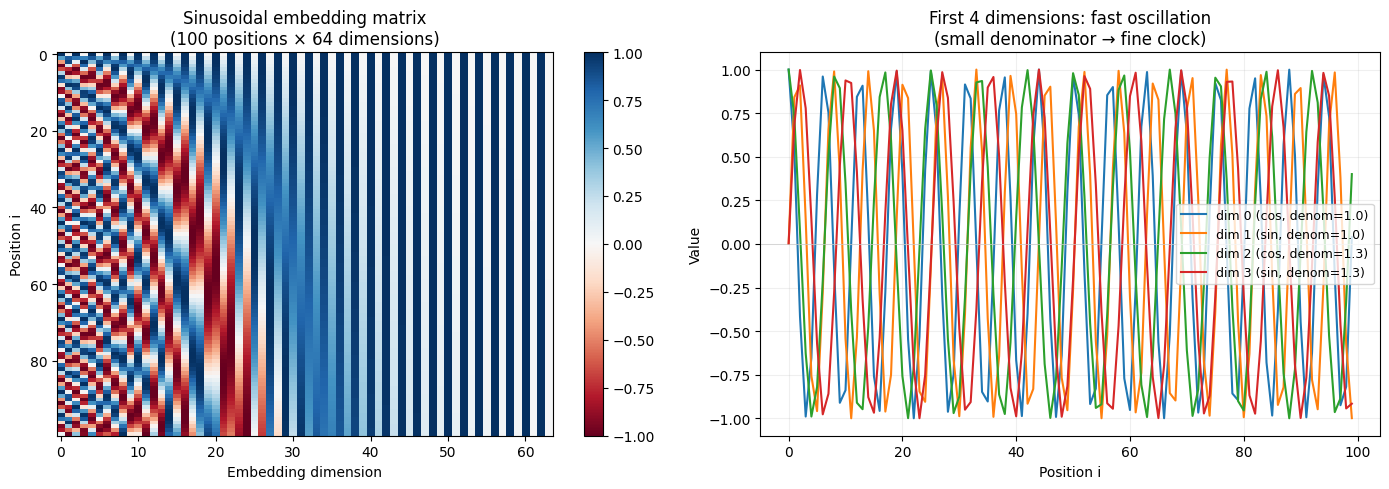

In [ ]:
# ── Cell 5: Embedding matrix heatmap (d=128, positions 0..199) ─────────────

def plot_embedding_matrix(d_model=64, max_len=100):
    """
    Visualise the full sinusoidal embedding matrix as a heatmap.
    Rows = positions, columns = embedding dimensions.
    """
    E = compute_embedding_matrix(max_len=max_len, d_model=d_model)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Full matrix heatmap
    im = axes[0].imshow(E, aspect='auto', cmap='RdBu', vmin=-1, vmax=1,
                        origin='upper', interpolation='nearest')
    axes[0].set_xlabel('Embedding dimension')
    axes[0].set_ylabel('Position i')
    axes[0].set_title(f'Sinusoidal embedding matrix\n'
                      f'({max_len} positions × {d_model} dimensions)')
    plt.colorbar(im, ax=axes[0])

    # First 4 dimensions over positions
    for k in range(4):
        denom = 10000 ** (2 * (k // 2) / d_model)
        label = (f'dim {k} (cos, denom={denom:.1f})'
                 if k % 2 == 0
                 else f'dim {k} (sin, denom={denom:.1f})')
        axes[1].plot(E[:, k], label=label, lw=1.5)

    axes[1].set_xlabel('Position i')
    axes[1].set_ylabel('Value')
    axes[1].set_title('First 4 dimensions: fast oscillation\n'
                      '(small denominator → fine clock)')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.2)
    axes[1].axhline(0, color='#ccc', lw=0.5)

    plt.tight_layout()
    plt.show()


plot_embedding_matrix(d_model=64, max_len=100)

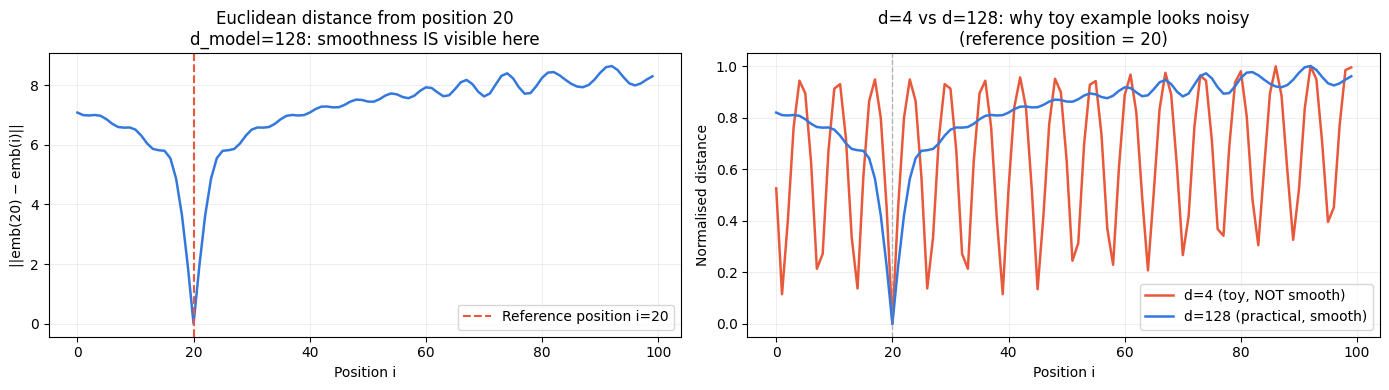

=== Chapter example (d=4) ===
emb(20) = [0.408 0.913 0.98  0.199]
emb(21) = [-0.548  0.837  0.978  0.208]
||emb(20) - emb(21)||  = 0.959  (not small — fast dim dominates)

=== d=128 (practical) ===
||emb(20) - emb(21)||  = 1.953
||emb(20) - emb(500)|| = 9.529  (4.9x larger)
→ Nearby positions ARE closer in d=128


In [ ]:
# ── Cell 6: Distances — smoothness property ────────────────────────────────

def plot_distances(d_model=128, max_len=100, ref_position=20):
    """
    Show ||emb(ref) - emb(i)|| for all i.
    Demonstrates that nearby positions produce similar embeddings
    (in high-dimensional space — not visible in d=4 toy example).
    """
    E = compute_embedding_matrix(max_len=max_len, d_model=d_model)
    ref = E[ref_position]
    distances = np.linalg.norm(E - ref, axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(distances, color='#3478dd', lw=1.8)
    axes[0].axvline(ref_position, color='#e8593c', lw=1.5, ls='--',
                    label=f'Reference position i={ref_position}')
    axes[0].set_xlabel('Position i')
    axes[0].set_ylabel(f'||emb({ref_position}) − emb(i)||')
    axes[0].set_title(f'Euclidean distance from position {ref_position}\n'
                      f'd_model={d_model}: smoothness IS visible here')
    axes[0].legend()
    axes[0].grid(True, alpha=0.2)

    # Compare d=4 (toy) vs d=128 (practical)
    for d, color, label in [(4, '#e8593c', 'd=4 (toy, NOT smooth)'),
                             (128, '#3478dd', 'd=128 (practical, smooth)')]:
        E_d = compute_embedding_matrix(max_len=max_len, d_model=d)
        ref_d = E_d[ref_position]
        dists_d = np.linalg.norm(E_d - ref_d, axis=1)
        # Normalise to [0,1] for comparison
        dists_norm = dists_d / dists_d.max()
        axes[1].plot(dists_norm, color=color, lw=1.8, label=label)

    axes[1].axvline(ref_position, color='#888', lw=1, ls='--', alpha=0.6)
    axes[1].set_xlabel('Position i')
    axes[1].set_ylabel('Normalised distance')
    axes[1].set_title(f'd=4 vs d=128: why toy example looks noisy\n'
                      f'(reference position = {ref_position})')
    axes[1].legend()
    axes[1].grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

    # Print the numbers from the chapter example
    E4 = compute_embedding_matrix(max_len=30, d_model=4)
    d_2021 = np.linalg.norm(E4[20] - E4[21])
    d_20500 = np.linalg.norm(
        compute_embedding_matrix(max_len=501, d_model=4)[20] -
        compute_embedding_matrix(max_len=501, d_model=4)[500]
    )
    print('=== Chapter example (d=4) ===')
    print(f'emb(20) = {np.round(E4[20], 3)}')
    print(f'emb(21) = {np.round(E4[21], 3)}')
    print(f'||emb(20) - emb(21)||  = {d_2021:.3f}  (not small — fast dim dominates)')

    E128 = compute_embedding_matrix(max_len=501, d_model=128)
    d128_2021  = np.linalg.norm(E128[20] - E128[21])
    d128_20500 = np.linalg.norm(E128[20] - E128[500])
    print(f'\n=== d=128 (practical) ===')
    print(f'||emb(20) - emb(21)||  = {d128_2021:.3f}')
    print(f'||emb(20) - emb(500)|| = {d128_20500:.3f}  ({d128_20500/d128_2021:.1f}x larger)')
    print('→ Nearby positions ARE closer in d=128')


plot_distances(d_model=128, max_len=100, ref_position=20)